# Content-Based Image Retrieval (CBIR) System 🔍

This project implements a Hybrid CBIR system to search and retrieve visually similar images from a database given a query image.

**Core Approach:**
1. **Local Features (SIFT + RANSAC):** Extracts keypoints and descriptors using Scale-Invariant Feature Transform. Uses Brute-Force matching and RANSAC Homography to find geometrically verified inliers.
2. **Color Features (HSV Histogram):** Uses Otsu's thresholding to remove the background, then computes color distribution via Intersection matching.
3. **Shape Features (Hu Moments):** Extracts global shape features and computes similarity using the inverse Euclidean distance.
4. **Hybrid Scoring:** Normalizes and fuses the scores from all three feature types using a weighted sum to rank the top matching results.

In [1]:
import os
import glob
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Configure global Matplotlib display settings for the result grid
plt.rcParams['figure.figsize'] = (16, 8)

## 1. Feature Database Construction
Functions to process the dataset and extract both local (SIFT) and global (Color, Shape) features into a unified dictionary.

In [2]:
def build_sift_database(db_directory):
    """Extracts SIFT features for all images in the specified database directory."""
    database = {}

    # Initialize SIFT with custom thresholds
    sift = cv2.SIFT_create(contrastThreshold=0.02, edgeThreshold=15)
    image_paths = glob.glob(os.path.join(db_directory, '*'))

    print(f"Extracting SIFT features for {len(image_paths)} images in the database...")
    for path in image_paths:
        img = cv2.imread(path)
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            kps, des = sift.detectAndCompute(gray, None)
            database[path] = (kps, des)

    print("SIFT extraction complete!")
    return database


def append_global_features(existing_db):
    """Appends Color Histograms and Hu Moments to the existing SIFT database."""
    hybrid_db = {}
    print("Extracting and appending global features (Color & Shape)...")

    for path, (kps, des) in existing_db.items():
        img = cv2.imread(path)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (5, 5), 0)

        # 1. Create mask to remove black background using Otsu's Thresholding
        _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # 2. Color Feature: HSV Color Histogram
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist([hsv], [0, 1, 2], mask, [8, 12, 3], [0, 180, 0, 256, 0, 256])
        cv2.normalize(hist, hist)
        hist = hist.flatten()

        # 3. Shape Feature: Hu Moments
        moments = cv2.moments(mask)
        hu = cv2.HuMoments(moments)

        # Apply Logarithmic transformation to normalize Hu Moments
        for i in range(0, 7):
            if hu[i][0] != 0:
                hu[i][0] = -1 * math.copysign(1.0, hu[i][0]) * math.log10(abs(hu[i][0]))
        hu = hu.flatten()

        # Combine all features into the hybrid database
        hybrid_db[path] = {
            'kps': kps,
            'des': des,
            'hist': hist,
            'hu': hu,
            'img': img
        }

    print("Global features successfully updated!")
    return hybrid_db

## 2. Image Matching & Retrieval Engine
Contains the Brute-Force keypoint matcher and the main Hybrid CBIR logic that calculates weighted similarity scores.

In [3]:
def match_keypoints(kpsA, kpsB, featuresA, featuresB, ratio):
    """Matches SIFT descriptors using Brute-Force Matcher and Lowe's ratio test."""
    bf = cv2.BFMatcher(cv2.NORM_L2)
    raw_matches = bf.knnMatch(featuresA, featuresB, k=2)
    matches = []

    for m, n in raw_matches:
        if m.distance < ratio * n.distance:
            matches.append(m)
    return matches


def cbir_hybrid(query_path, hybrid_db, top_k=5, weights=(0.5, 0.3, 0.2), ratio=0.75):
    """
    Main CBIR function calculating similarity based on SIFT, Color, and Shape.
    Returns and visualizes the top_k matching images.
    """
    w_sift, w_color, w_shape = weights

    img_q = cv2.imread(query_path)
    if img_q is None:
        print(f"Failed to load query image at: {query_path}")
        return []

    gray_q = cv2.cvtColor(img_q, cv2.COLOR_BGR2GRAY)

    # ====================================================
    # 1. EXTRACT QUERY LOCAL FEATURES (SIFT)
    # ====================================================
    sift = cv2.SIFT_create(contrastThreshold=0.02, edgeThreshold=15)
    kps_q, des_q = sift.detectAndCompute(gray_q, None)

    # ====================================================
    # 2. EXTRACT QUERY GLOBAL FEATURES (Color + Shape)
    # ====================================================
    blur_q = cv2.GaussianBlur(gray_q, (5, 5), 0)
    _, mask_q = cv2.threshold(blur_q, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Color Histogram
    hsv_q = cv2.cvtColor(img_q, cv2.COLOR_BGR2HSV)
    hist_q = cv2.calcHist([hsv_q], [0, 1, 2], mask_q, [8, 12, 3], [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist_q, hist_q)
    hist_q = hist_q.flatten()

    # Hu Moments
    moments_q = cv2.moments(mask_q)
    hu_q = cv2.HuMoments(moments_q)
    for i in range(0, 7):
        if hu_q[i][0] != 0:
            hu_q[i][0] = -1 * math.copysign(1.0, hu_q[i][0]) * math.log10(abs(hu_q[i][0]))
    hu_q = hu_q.flatten()

    # ====================================================
    # 3. SCORE AGAINST DATABASE IMAGES
    # ====================================================
    raw_results = []
    max_sift_matches = 0

    for db_path, db_feat in hybrid_db.items():
        # --- SIFT Matching with RANSAC Geometric Verification ---
        inliers = 0
        if des_q is not None and db_feat['des'] is not None:
            matches = match_keypoints(kps_q, db_feat['kps'], des_q, db_feat['des'], ratio)

            # Require minimum 4 points to compute Homography
            if len(matches) >= 4:
                src_pts = np.float32([kps_q[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
                dst_pts = np.float32([db_feat['kps'][m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

                # Find Homography Matrix and filter out outliers
                M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
                if mask is not None:
                    inliers = np.sum(mask)

        sift_score = inliers
        if sift_score > max_sift_matches:
            max_sift_matches = sift_score

        # --- Color Histogram Matching (Intersection) ---
        color_score = cv2.compareHist(hist_q, db_feat['hist'], cv2.HISTCMP_INTERSECT)

        # --- Hu Moments Matching (Inverse Euclidean Distance) ---
        shape_dist = np.linalg.norm(hu_q - db_feat['hu'])
        shape_score = 1.0 / (1.0 + shape_dist)

        raw_results.append({
            'path': db_path,
            'img': db_feat['img'],
            'sift_raw': sift_score,
            'color_score': color_score,
            'shape_score': shape_score
        })

    # ====================================================
    # 4. FINAL SCORING & RANKING
    # ====================================================
    final_results = []
    for res in raw_results:
        # Normalize SIFT score to [0, 1] range based on max matches found
        sift_norm = res['sift_raw'] / max_sift_matches if max_sift_matches > 0 else 0

        total_score = (w_sift * sift_norm) + (w_color * res['color_score']) + (w_shape * res['shape_score'])

        final_results.append({
            'path': res['path'],
            'img': res['img'],
            'total_score': total_score,
            'details': f"SIFT: {sift_norm:.2f}\nColor: {res['color_score']:.2f}\nShape: {res['shape_score']:.2f}"
        })

    # Sort results by descending total score
    final_results = sorted(final_results, key=lambda x: x['total_score'], reverse=True)[:top_k]

    # ====================================================
    # 5. VISUALIZE RESULTS IN A GRID
    # ====================================================
    plt.figure(figsize=(16, 8))
    num_rows_for_grid = math.ceil(top_k / 5) + 1

    # Display Query Image
    plt.subplot(num_rows_for_grid, 5, 1)
    plt.title("Query Image", color="red", fontweight="bold")
    plt.imshow(cv2.cvtColor(img_q, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    # Display Top K Results
    for i, res in enumerate(final_results):
        plt.subplot(num_rows_for_grid, 5, i + 6)
        plt.title(f"Top {i+1} | Score: {res['total_score']:.2f}\n{res['details']}", fontsize=9)
        plt.imshow(cv2.cvtColor(res['img'], cv2.COLOR_BGR2RGB))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    return final_results

## 3. Run Pipeline
Set up directories, build the feature database, and run a sample query.

In [4]:
# 1. Define standard directory structures (Relative paths instead of Colab absolute paths)
db_dir = 'database'
query_dir = 'query'

os.makedirs(db_dir, exist_ok=True)
os.makedirs(query_dir, exist_ok=True)

print(f"Directory setup complete.")
print(f"Please ensure your dataset images are placed in the '{db_dir}' folder.")
print(f"Please place your query image (e.g., 'sample_query.png') in the '{query_dir}' folder.")

#2. Build the Hybrid Feature Database
base_sift_db = build_sift_database(db_dir)
hybrid_database = append_global_features(base_sift_db)

Directory setup complete.
Please ensure your dataset images are placed in the 'database' folder.
Please place your query image (e.g., 'sample_query.png') in the 'query' folder.
Extracting SIFT features for 60 images in the database...
SIFT extraction complete!
Extracting and appending global features (Color & Shape)...
Global features successfully updated!


In [5]:
# 1. Define the directory for images
image_dir = 'query'

# 2. Automatically download a sample image if it doesn't exist
# (It ensures the Notebook runs smoothly even if the user hasn't downloaded the repo)
sample_filename = 'obj1_100.png'
sample_path = os.path.join(image_dir, sample_filename)

if not os.path.exists(sample_path):
    print(f"Sample image not found at '{sample_path}'. Attempting to download...")
    os.makedirs(image_dir, exist_ok=True)

    # Replace this URL with the raw link to image on Github
    sample_url = 'https://raw.githubusercontent.com/kietnguyen-0902/Hybrid-CBIR-System/refs/heads/main/query/obj1__110.png'

    try:
        urllib.request.urlretrieve(sample_url, sample_path)
        print("Download successful!")
    except Exception as e:
        print(f"Failed to download image. Error: {e}")
        print("Please upload the image manually or check the URL.")

# 3. List all available images in the directory for easy reference
if os.path.exists(image_dir):
    # Filter only image files to avoid clutter
    available_images = [f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Available images in '{image_dir}': {available_images}")

Sample image not found at 'query/obj1_100.png'. Attempting to download...
Download successful!
Available images in 'query': ['obj1__350.png', 'obj6__300.png', 'obj3__295.png', 'obj2__355.png', 'obj5__355.png', 'obj5__350.png', 'obj4__345.png', 'obj2__350.png', 'obj3__350.png', 'obj3__355.png', 'obj3__300.png', 'obj1__110.png', 'obj1__115.png', 'obj4__350.png', 'obj1__355.png', 'obj1_100.png', 'obj6__350.png']


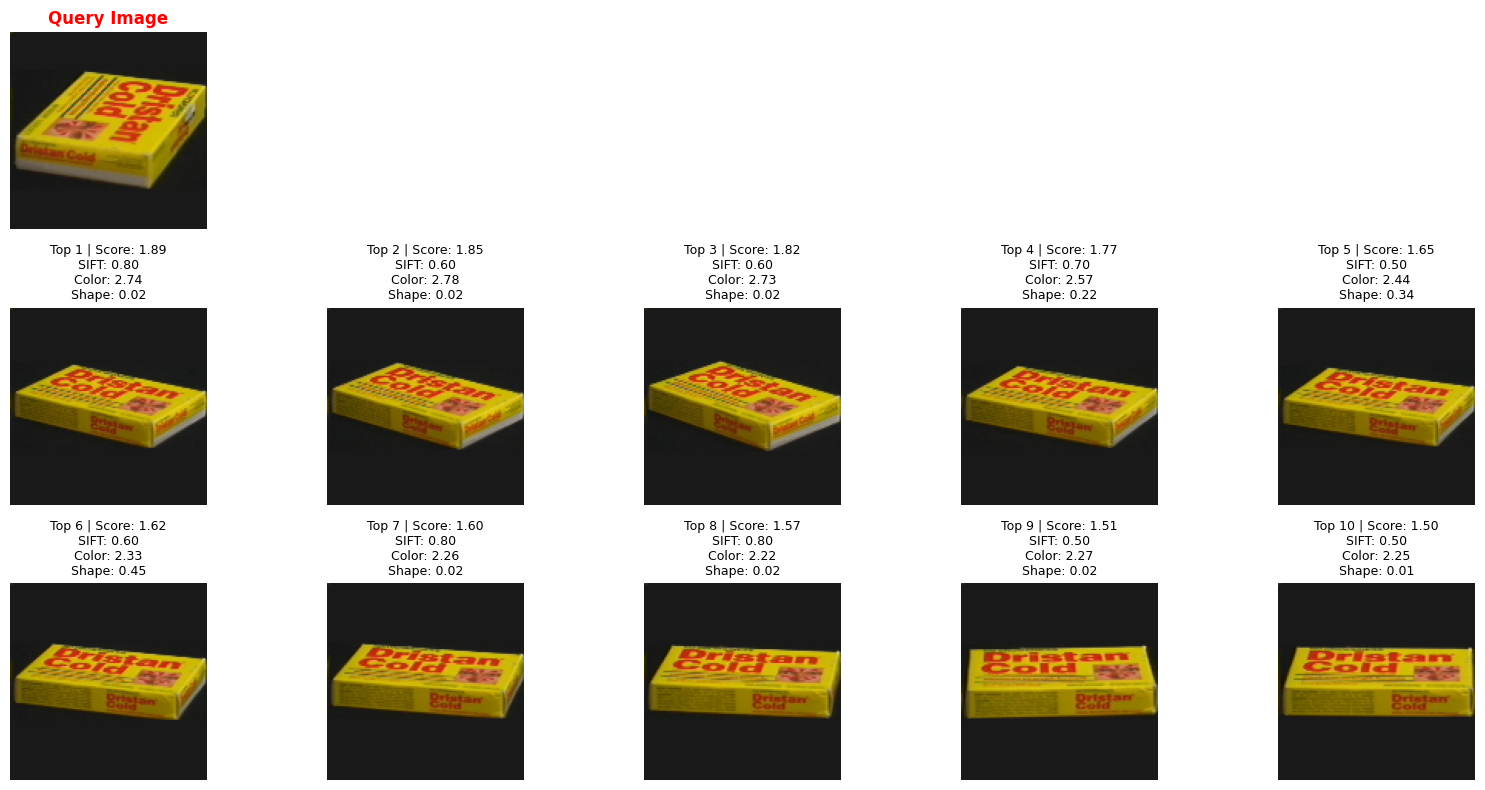

In [6]:
#1. Define the query image path
query_image_filename = 'obj1__110.png'
query_image_path = os.path.join(query_dir, query_image_filename)

#2. Run the CBIR Search
#Weights structure: (SIFT weight, Color weight, Shape weight)
results_hybrid = cbir_hybrid(
    query_path=query_image_path,
    hybrid_db=hybrid_database,
    top_k=10,
    weights=(0.3, 0.6, 0.1)
)